[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/06-ai-ethics-medicine.ipynb)

# AI Ethics in Medicine

**ELMED219 / BMED365 - Lab 3**

Last updated:<br>
2026-01-03, A. Lundervold

---

## Learning Objectives

After this notebook, you should be able to:
- Identify ethical challenges with AI in healthcare
- Explain different types of bias in medical AI systems
- Discuss privacy considerations when using AI on health data
- Describe relevant regulations (EU AI Act)
- Reflect on responsibility and transparency

## Contents

1. [Ethical Challenges](#1-ethical-challenges)
2. [Bias in Medical AI](#2-bias-in-medical-ai)
3. [Privacy and Data Security](#3-privacy-and-data-security)
4. [Regulation and EU AI Act](#4-regulation-and-eu-ai-act)
5. [Responsibility and Decision-Making](#5-responsibility-and-decision-making)
6. [Best Practices](#6-best-practices)

---

## 1. Ethical Challenges

AI in healthcare raises fundamental ethical questions that touch upon the four principles of medical ethics:

| Principle | AI Challenge |
|----------|---------------|
| **Autonomy** | Does AI affect the patient's free choice? Does the patient understand that AI is being used? |
| **Beneficence** | Does AI actually provide better outcomes for the patient? |
| **Non-maleficence** | Can AI errors lead to harm? Who is responsible? |
| **Justice** | Is AI fair across patient groups? |

### Examples of Ethical Dilemmas

**Case 1: Resource Allocation**
> An AI predicts that patient A has an 80% chance of surviving intensive care, while patient B has 40%. Should the AI prediction determine who gets the intensive care bed?

**Case 2: Autonomy vs. Safety**
> A patient refuses treatment based on an AI recommendation, but wants treatment that the AI advises against. How should the patient's autonomy be weighed against the AI recommendation?

**Case 3: Transparency**
> A complex AI model provides better diagnoses than doctors, but cannot explain why. Should it be used?

In [2]:
# Framework for ethical assessment of AI systems

def ethical_checklist(ai_system):
    """
    Checklist for ethical assessment of a medical AI system.
    """
    checklist = {
        "Transparency": [
            "Is it clear to patients that AI is being used?",
            "Can decisions be explained?",
            "Is training data documented?"
        ],
        "Fairness": [
            "Has the model been tested on diverse populations?",
            "Are there known biases in the data?",
            "Is performance monitored across groups?"
        ],
        "Privacy": [
            "How is patient data handled?",
            "Has consent been obtained?",
            "Can data be de-anonymized?"
        ],
        "Responsibility": [
            "Who is responsible in case of errors?",
            "Is there human oversight?",
            "How are decisions logged?"
        ],
        "Safety": [
            "What happens if the system fails?",
            "Are there backup procedures?",
            "How is the model updated?"
        ]
    }
    return checklist

checklist = ethical_checklist("Diagnostic Support AI")

print("ETHICAL CHECKLIST FOR MEDICAL AI")
print("=" * 50)
for category, questions in checklist.items():
    print(f"\n{category}:")
    for q in questions:
        print(f"  □ {q}")

ETHICAL CHECKLIST FOR MEDICAL AI

Transparency:
  □ Is it clear to patients that AI is being used?
  □ Can decisions be explained?
  □ Is training data documented?

Fairness:
  □ Has the model been tested on diverse populations?
  □ Are there known biases in the data?
  □ Is performance monitored across groups?

Privacy:
  □ How is patient data handled?
  □ Has consent been obtained?
  □ Can data be de-anonymized?

Responsibility:
  □ Who is responsible in case of errors?
  □ Is there human oversight?
  □ How are decisions logged?

Safety:
  □ What happens if the system fails?
  □ Are there backup procedures?
  □ How is the model updated?


---

## 2. Bias in Medical AI

Bias in AI systems can lead to systematically unfair treatment of patient groups.

### Types of Bias

| Type | Description | Example |
|------|-------------|----------|
| **Historical Bias** | Training data reflects past unfairness | Women underdiagnosed for heart disease |
| **Representation Bias** | Some groups underrepresented in data | Little data from non-Western populations |
| **Measurement Bias** | Different measurement methods for different groups | Skin color affects pulse oximeters |
| **Aggregation Bias** | Same model for everyone, ignores subgroups | One diabetes model for all age groups |

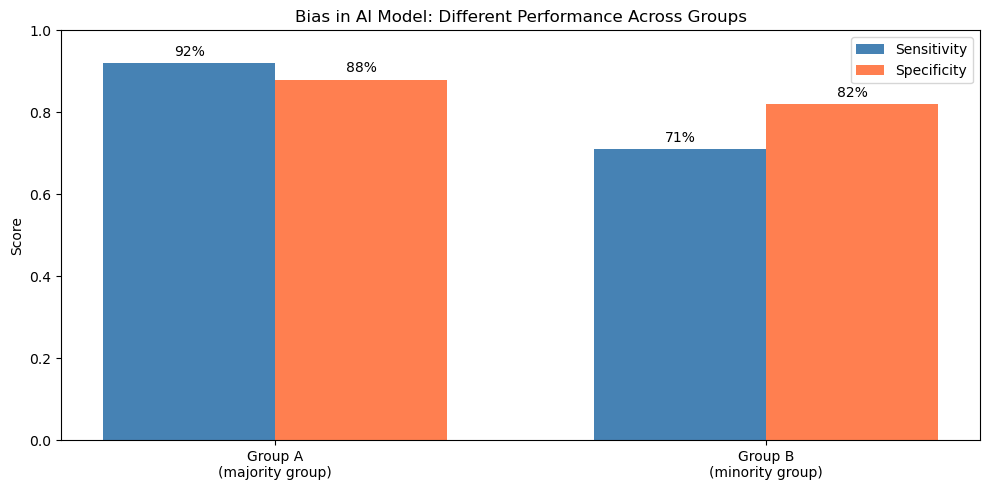


Consequence:
  - Group B has 21% lower sensitivity
  - This means more people in group B receive false 'healthy' diagnoses
  - Such disparities can exacerbate existing health inequalities


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstration of bias in a hypothetical AI model

def simulate_bias_example():
    """
    Simulates an AI model with different performance across different groups.
    Based on real observations from medical AI research.
    """
    groups = ['Group A\n(majority group)', 'Group B\n(minority group)']
    
    # Simulated performance metrics
    sensitivity = [0.92, 0.71]  # How well the model detects disease
    specificity = [0.88, 0.82]  # How well the model excludes healthy cases
    
    return groups, sensitivity, specificity

groups, sens, spec = simulate_bias_example()

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(groups))
width = 0.35

bars1 = ax.bar(x - width/2, sens, width, label='Sensitivity', color='steelblue')
bars2 = ax.bar(x + width/2, spec, width, label='Specificity', color='coral')

ax.set_ylabel('Score')
ax.set_title('Bias in AI Model: Different Performance Across Groups')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()
ax.set_ylim(0, 1)

# Add values on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.0%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nConsequence:")
print(f"  - Group B has {(sens[0]-sens[1])*100:.0f}% lower sensitivity")
print(f"  - This means more people in group B receive false 'healthy' diagnoses")
print(f"  - Such disparities can exacerbate existing health inequalities")

### Real Examples of Bias

1. **Skin Cancer Detection**: Models trained primarily on light-skinned populations perform worse on darker skin

2. **Pulse Oximeters**: Overestimate oxygen saturation in dark-skinned patients

3. **Pain Treatment**: Historical underestimation of pain in minorities is reflected in data

4. **Gender Differences**: Heart disease symptoms present differently in women, but models are often trained on male-dominated datasets

---

## 3. Privacy and Data Security

Health data is among the most sensitive personal information and requires special protection.

### GDPR and Health Data

Under GDPR, health data is a "special category" that requires:

- Explicit consent or other legal basis
- Strict security measures
- Data minimization (only necessary data)
- Right to access and deletion

In [4]:
# Privacy risk assessment

def privacy_risk(scenario):
    """
    Assess privacy risk for an AI scenario.
    """
    risks = {
        "cloud_service": {
            "description": "AI runs in external cloud service",
            "risks": [
                "Data sent outside the organization",
                "Third-party vendor has access",
                "Uncertain where data is stored geographically",
                "Data may be used for model training"
            ],
            "measures": [
                "Data Processing Agreement (DPA)",
                "Verify EU storage",
                "Encryption in transit and at rest",
                "Opt-out from training data"
            ]
        },
        "local_model": {
            "description": "AI runs locally on hospital infrastructure",
            "risks": [
                "Internal access control",
                "Logging and traceability",
                "Updates and maintenance"
            ],
            "measures": [
                "Role-based access",
                "Audit logging",
                "Secure update routine"
            ]
        }
    }
    return risks.get(scenario, {})

print("PRIVACY RISK ASSESSMENT")
print("=" * 50)

for scenario in ["cloud_service", "local_model"]:
    info = privacy_risk(scenario)
    print(f"\n{info['description'].upper()}")
    print("-" * 40)
    print("Risks:")
    for r in info['risks']:
        print(f"  ⚠ {r}")
    print("Measures:")
    for t in info['measures']:
        print(f"  ✓ {t}")

PRIVACY RISK ASSESSMENT

AI RUNS IN EXTERNAL CLOUD SERVICE
----------------------------------------
Risks:
  ⚠ Data sent outside the organization
  ⚠ Third-party vendor has access
  ⚠ Uncertain where data is stored geographically
  ⚠ Data may be used for model training
Measures:
  ✓ Data Processing Agreement (DPA)
  ✓ Verify EU storage
  ✓ Encryption in transit and at rest
  ✓ Opt-out from training data

AI RUNS LOCALLY ON HOSPITAL INFRASTRUCTURE
----------------------------------------
Risks:
  ⚠ Internal access control
  ⚠ Logging and traceability
  ⚠ Updates and maintenance
Measures:
  ✓ Role-based access
  ✓ Audit logging
  ✓ Secure update routine


### Special Considerations for LLMs

Large Language Models (LLMs) raise unique privacy questions:

1. **Memorization**: LLMs can remember and repeat sensitive information from training
2. **Prompt Injection**: Malicious prompts can attempt to extract sensitive data
3. **Training Data**: Uncertainty about what the model was trained on
4. **API Logging**: Cloud vendors may log all prompts

---

## 4. Regulation and EU AI Act

EU AI Act (2024) is the world's first comprehensive AI regulation.

### Risk-Based Approach

```
┌─────────────────────────────────────────────────────────┐
│  PROHIBITED                                             │
│  Social scoring, manipulative AI, biometric ID in       │
│  public spaces                                          │
├─────────────────────────────────────────────────────────┤
│  HIGH RISK                                              │
│  Medical devices, critical infrastructure,              │
│  recruitment, education                                 │
│  → Strict requirements for documentation, testing,      │
│     oversight                                           │
├─────────────────────────────────────────────────────────┤
│  LIMITED RISK                                           │
│  Chatbots, deepfakes                                    │
│  → Transparency requirements ("You are talking to AI")  │
├─────────────────────────────────────────────────────────┤
│  MINIMAL RISK                                           │
│  Most AI systems                                        │
│  → No special requirements                              │
└─────────────────────────────────────────────────────────┘
```

### Requirements for High-Risk AI (including medical)

- Risk assessment and management
- Data quality management
- Technical documentation
- Logging and traceability
- Transparency to users
- Human oversight
- Robustness and cybersecurity

---

## 5. Responsibility and Decision-Making

### Who is Responsible?

When AI errors occur in healthcare, the distribution of responsibility is complex:

| Actor | Potential Responsibility |
|-------|-------------------|
| **The Doctor** | Clinical decision, use of AI as a tool |
| **The Hospital** | System selection, implementation, training |
| **AI Vendor** | Product liability, documentation |
| **Data Controller** | Data quality, privacy |

### Human-in-the-Loop

An important principle is that humans should always be able to:
- Override AI decisions
- Understand the basis for recommendations
- Choose not to use AI

---

## 6. Best Practices

### Ethical Use of AI in Healthcare

**Before Implementation:**
- Conduct ethical assessment
- Test for bias across different populations
- Establish clear lines of responsibility
- Ensure privacy compliance

**During Use:**
- Provide training to users
- Monitor performance continuously
- Log all AI decisions
- Have procedures for human override

**Communication:**
- Inform patients about AI use
- Be transparent about limitations
- Do not oversell AI capabilities

---

## Summary

### Key Points

1. **Ethical Principles** (autonomy, beneficence, non-maleficence, justice) also apply to AI
2. **Bias** can exacerbate existing health disparities if not addressed
3. **Privacy** requires special measures for health data, especially with cloud services
4. **EU AI Act** classifies medical AI as high-risk with strict requirements
5. **Responsibility** is shared among many actors, but the doctor retains clinical responsibility

### Reflection Questions

1. How would you explain to a patient that AI is being used in their treatment?
2. What measures would you implement to detect bias in an AI model?
3. Should doctors be held responsible for AI errors they could not foresee?

---

*Next notebook: [07 - Trustworthy AI](07-trustworthy-ai.ipynb)*